# Abstract
___

This report calculates a couple of key metrics that help assess the recurring revenue health of the business:

- ARR (Annual Recurring Revenue) – Predictable yearly income from active licenses.
- MRR (Monthly Recurring Revenue) – Predictable monthly income from the same customer base.
- ARPU (Average Revenue Per User) – Average monthly revenue generated per active customer.

To calculate these metrics, we will need:

- data on the sales amount split by months of actual use,
- license duration.

We don't have this data, but we can calculate it.

In [1]:
from working_with_db import *
from make_chart import *

conn = connect_to_local_postgresql(db_name='postgres', user='jet', password='brains')

metrics_df = execute_query_to_dataframe(conn, read_sql_file_to_string('metrics/mrr_and_arr.sql'))
price_and_duration_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'metrics/price_and_duration_of_licenses.sql'))

mrr_df = metrics_df[metrics_df['metric_name'] == 'MRR']
arr_df = metrics_df[metrics_df['metric_name'] == 'ARR']
arpu_df = metrics_df[metrics_df['metric_name'] == 'ARPU']

# Preparation

1. **Sales segmentation**

We will remove one-time payments from the total number of sales, since these metrics show recurring income.\
We exclude new users who have paid only once.\

2. **Licenses are classified based on price per license:**

From [jetbrains.com/store](https://www.jetbrains.com/store), we know that there are two types of licenses - monthly and annual.\
If the monthly subscription price is X, then the annual one is 10X.\
Let's confirm this idea with data.

The graph shows the spread of license prices for product X.

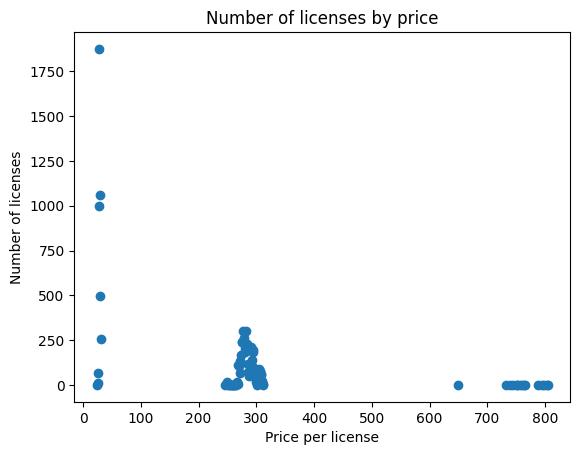

In [2]:
make_chart(dataframe=price_and_duration_df,
           x_column='license_cost', y_column='number_of_licenses',
           chart_type=ChartType.SCATTER, title='Number of licenses by price',
           xlabel='Price per license', ylabel='Number of licenses')

All prices are split into 3 groups:

- monthly license for individual users.
- annual license for individual users.
- annual license for organizations.

The price charts for the other products look similar.\
Based on this chart and the data from the web page, I decided that subscriptions under 35 USD are monthly, and those over 35 USD are annual.


3. **Payment splitting logic:**

Example, a monthly license: a customer bought a monthly license on 11th April, for 10 USD. There are 30 days in April.\
I spread 2/3 of this amount in April and 1/3 in May.

Example, an annual license: a customer purchased an annual license on 11th April 2019, for 120 USD.\
I distribute 10 USD for all full months of the license (from May 2019 to March 2020), which is 11 months.
The last 10 USD is distributed according to the monthly license rule between April 2019 and April 2020.

4. **License validity period**

To simplify the calculation, I assume that the license is activated on the day of purchase.

5. **Data context**

The data covers the period from January 2018 to December 2020.\
But 2018 revenue is affected by 2017 license sales. 2021 revenue is affected by 2021 sales.\
Due to the limited data period, we cannot add 2018 and 2021 to the chart.\

# Metrics

## MRR (Monthly Recurring Revenue)

---

MRR = Σ (licenses_price / license_length_in_months)

**Observations**

Growth from the beginning of 2019 to the end of 2020.\
MRR shows a stable linear growth during this period.
This indicates a stable growth in new licenses.

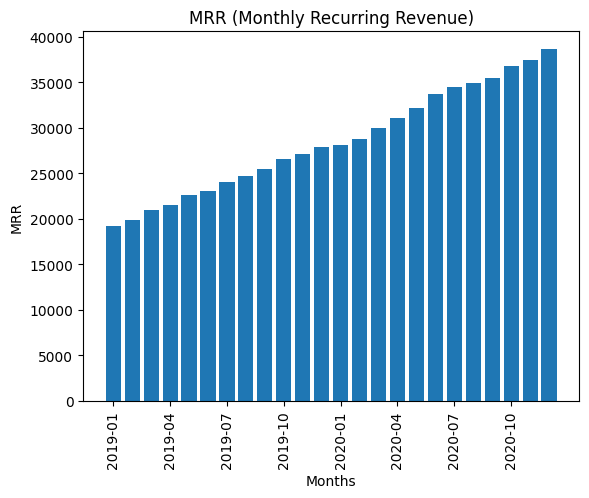

In [3]:
make_chart(dataframe=mrr_df,
           x_column='dt', y_column='value',
           chart_type=ChartType.BAR,
           title='MRR (Monthly Recurring Revenue)',
           xlabel='Months', ylabel='MRR', xticks=3, xticks_rotation=90)


## ARR (Annual Recurring Revenue)
___

 ARR = MRR * 12

**Observations**

The ARR chart confirms the long-term stability of revenues shown in the MRR chart.

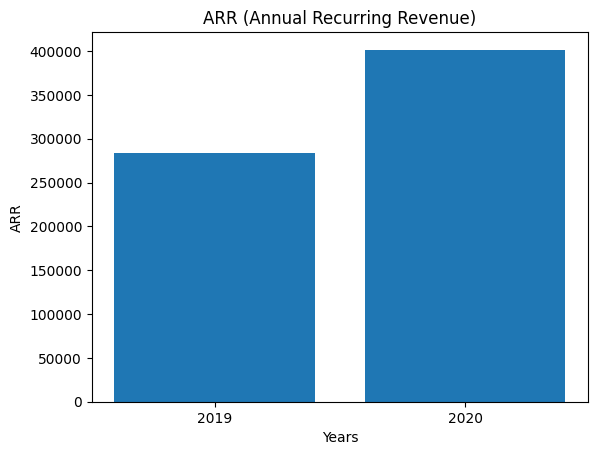

In [4]:
make_chart(dataframe=arr_df,
           x_column='dt', y_column='value',
           chart_type=ChartType.BAR,
           title='ARR (Annual Recurring Revenue)',
           xlabel='Years', ylabel='ARR')

## ARPU (Average Revenue Per User)

---

ARPU = MRR / number_of_customers_with_active_license.

**Observations**

ARPU is decreasing during this period.

**Possible reasons:**

- Growth in lower-priced licenses.
- Acquisition of new customers with smaller average payments.

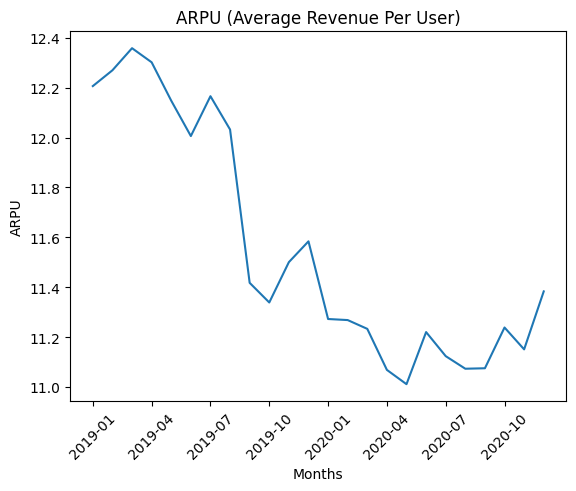

In [5]:
make_chart(dataframe=arpu_df,
           x_column='dt', y_column='value',
           chart_type=ChartType.LINE,
           title='ARPU (Average Revenue Per User)',
           xlabel='Months', ylabel='ARPU', xticks=3, xticks_rotation=45)